# Imports & Loads

In [1]:
# PATHS
TRAIN_PATH    = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\train.csv'
TEST_PATH     = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\test.csv'
SAMPLE_PATH   = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\sample_submission.csv'
ORIGINAL_PATH = r'C:\Users\harwi\Downloads\student_health_risk_prediction_system\student_health_dataset_50k.csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from utils.evaluation import evaluate_oof
from utils.feature_engineering import engineer_features
from utils.probes import train_probe
from utils.final_probe import train_final_probe
from utils.predict_proba import predict_probe
import importlib
import utils.feature_engineering
from utils.feature_engineering import prepare_fold
from utils.error_analysis import analyze_errors

# importlib.reload(utils.feature_engineering)
import warnings
warnings.filterwarnings('ignore')

N_FOLDS   = 5
SEED      = 42
N_CLASSES = 3

train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

TARGET       = 'health_condition'
CLASS_COLORS = {'fit': '#55A868', 'at-risk': '#4C72B0', 'unhealthy': '#C44E52'}

CAT_COLS = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']
NUM_COLS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
            'step_count', 'exercise_duration', 'water_intake']

for df in [train, test, original]:
    for c in CAT_COLS:
        df[c] = df[c].astype(str).str.strip().str.lower().replace('nan', np.nan)

original[TARGET] = original[TARGET].astype(str).str.strip().str.lower()
original = original.drop(columns=['student_id', 'timestamp'])

print(f'Train    : {train.shape}')
print(f'Test     : {test.shape}')
print(f'Original : {original.shape}')

Train    : (690088, 15)
Test     : (295753, 14)
Original : (50000, 14)


In [3]:
id_train = train['id'].copy()
id_test = test['id'].copy()

train.drop(columns=['id'],inplace=True)
test.drop(columns=['id'],inplace=True)

In [4]:
STRESS_MISSING_TR = train['stress_level'].isna().values
STRESS_MISSING_TE = test['stress_level'].isna().values
SLEEP_MISSING_TR  = train['sleep_duration'].isna().values
SLEEP_MISSING_TE  = test['sleep_duration'].isna().values

print(f'train stress missing: {STRESS_MISSING_TR.sum():,} ({STRESS_MISSING_TR.mean()*100:.1f}%)')
print(f'test  stress missing: {STRESS_MISSING_TE.sum():,} ({STRESS_MISSING_TE.mean()*100:.1f}%)')
print(f'train sleep_duration missing : {SLEEP_MISSING_TR.sum():}({SLEEP_MISSING_TR.mean()*100:.1f}%')
print(f'test Sleep_duration missng   : {SLEEP_MISSING_TE.sum():}({SLEEP_MISSING_TE.mean()*100:.1f}%)')

train stress missing: 82,811 (12.0%)
test  stress missing: 35,490 (12.0%)
train sleep_duration missing : 75999(11.0%
test Sleep_duration missng   : 32571(11.0%)


# Feature Engineering

In [5]:
train    = engineer_features(train)
test     = engineer_features(test)
original = engineer_features(original)

ENGINEERED_CATS = ['stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke','sleep_x_stress']
ENGINEERED_NUMS = ['sleep_lt6', 'sleep_ge7', 'steps_x_exercise',
                   'activity_efficiency', 'sleep_x_steps', 'bmi_band', 'sleep_dev']

FEATURES  = NUM_COLS + CAT_COLS + ENGINEERED_CATS + ENGINEERED_NUMS
MODEL_CATS = CAT_COLS + ENGINEERED_CATS
print(f'{len(FEATURES)} features ({len(MODEL_CATS)} categorical)')

24 features (10 categorical)


# Stress Level Recovery Probe

In [ ]:
stress_leak_features =['stress_level','stress_x_activity','stress_x_sleepq','stress_x_smoke','sleep_x_stress',TARGET]

stress_probe = train_probe(train=train,target='stress_level',features = FEATURES, categorical_cols=MODEL_CATS, missing_mask= STRESS_MISSING_TR,
                           leak_features=stress_leak_features, seed=SEED,n_splits=5)

## Training a single model for stress probe

In [7]:
final_stress_probe = train_final_probe(train=train, target = 'stress_level',features = FEATURES, categorical_cols=MODEL_CATS, missing_mask= STRESS_MISSING_TR,
                leak_features=stress_leak_features, seed=SEED)

probs_train_stress = predict_probe(train,final_stress_probe)

le = final_stress_probe['label_encoder']

for i, cls in enumerate(le.classes_):
    train[f"p_stress_{cls}"] = probs_train_stress[:, i]

probs_test_stress = predict_probe(test,final_stress_probe)
for i,cls in enumerate(le.classes_):
    test[f'p_stress_{cls}'] = probs_test_stress[:,i]

In [17]:
import joblib

joblib.dump(
    final_stress_probe,
    "../models/stress_probe_1.pkl"
)


['../models/stress_probe_1.pkl']

In [7]:
# Updating FEATURES and MODEL_CATS varable beacuse 3 new features just got added

FEATURES = [col for col in train.columns.tolist() if col !=TARGET]
MODEL_CATS = [col for col in train.select_dtypes(include='object').columns.tolist() if col != TARGET]

# Sleep Duration Recovery Probe

In [8]:
y_region = np.digitize(
    train["sleep_duration"],
    bins=[6.0, 7.0]
)

train_copy = train.copy()
train_copy['y_region'] = y_region

sleep_leak = ['sleep_lt6','sleep_ge7','sleep_dev','sleep_x_steps','sleep_duration',TARGET]

# sleep_probe_result = train_probe(
#     train= train_copy,
#     target = 'y_region',
#     features=FEATURES,
#     categorical_cols=MODEL_CATS,
#     leak_features=sleep_leak,
#     missing_mask= SLEEP_MISSING_TR,
#     seed=SEED,
#     n_splits=5   
# )

In [9]:
from utils.final_probe import train_final_probe
from utils.predict_proba import predict_probe
import joblib

final_sleep_probe = train_final_probe(train=train_copy, target = 'y_region',features = FEATURES, categorical_cols=MODEL_CATS, missing_mask= SLEEP_MISSING_TR,
                leak_features=sleep_leak, seed=SEED)



probs_train_sleep = predict_probe(train,final_sleep_probe)

le = final_sleep_probe['label_encoder']

for i, cls in enumerate(le.classes_):
    train[f"p_sleep_{cls}"] = probs_train_sleep[:, i]

probs_test_sleep = predict_probe(test,final_sleep_probe)

for i,cls in enumerate(le.classes_):
    test[f'p_sleep_{cls}'] = probs_test_sleep[:,i]

In [18]:
joblib.dump(
    final_sleep_probe,
    "../models/sleep_probe_1.pkl"
)

['../models/sleep_probe_1.pkl']

In [10]:
# Updating FEATURES and MODEL_CATS varable beacuse 3 new features just got added

FEATURES = [col for col in train.columns.tolist() if col !=TARGET]
MODEL_CATS = [col for col in train.select_dtypes(include='object').columns.tolist() if col != TARGET]

# Applying 5 fold Cross Validation

In [11]:
le = LabelEncoder()
y = le.fit_transform(train[TARGET])

print("Class encoding: ",dict(zip(le.classes_,range(len(le.classes_)))))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
FOLD_SPLITS = list(skf.split(train,y))

oof_probs = np.zeros((len(train),N_CLASSES))
test_probs = np.zeros((len(test),N_CLASSES))

fold_scores = []
models = []
fi_list = []
encoding_infos = []

cat_cols = [col for col in train.select_dtypes(include = 'object').columns if col != TARGET]



Class encoding:  {'at-risk': 0, 'fit': 1, 'unhealthy': 2}


Handling missing values

In [12]:
def handle_sleep_duration(df):
    df = df.copy()

    df["sleep_missing"] = (
        df["sleep_duration"].isna().astype(np.int8)
    )

    sleep_cols = [
        "sleep_duration",
        "sleep_lt6",
        "sleep_ge7",
        "sleep_dev",
        "sleep_x_steps"
    ]

    df[sleep_cols] = df[sleep_cols].fillna(-1)

    return df

train = handle_sleep_duration(train)
test = handle_sleep_duration(test)


In [13]:
for col in MODEL_CATS:
    train[col] = train[col].fillna("missing").astype(str)
    test[col] = test[col].fillna("missing").astype(str)

In [ ]:
XGB_PARAMS = dict(
    objective="multi:softprob",
    num_class=N_CLASSES,

    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,

    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=5,

    random_state=SEED,

    tree_method="hist",
    device="cuda",

    eval_metric="mlogloss",
)

In [15]:
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder

for fold, (tr_idx, val_idx) in enumerate(FOLD_SPLITS, 1):

    print(f"\nFold {fold}")

    (train_fold,valid_fold,test_fold,encoding_info) = prepare_fold(
            train_df=train,
            test_df = test,
            train_idx=tr_idx,
            valid_idx=val_idx,
            cat_cols= cat_cols,
            target=TARGET
        )
    

    encoding_infos.append(encoding_info)

    FEATURES_FOLD = [
        col for col in train_fold.columns
        if col != TARGET
    ]

    CAT_FEATURES = [
        col
        for col in train_fold.select_dtypes(
            include="object"
        ).columns
        if col != TARGET
    ]


    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    train_fold[CAT_FEATURES] = encoder.fit_transform(
        train_fold[CAT_FEATURES]
    )

    valid_fold[CAT_FEATURES] = encoder.transform(
        valid_fold[CAT_FEATURES]
    )

    test_fold[CAT_FEATURES] = encoder.transform(
        test_fold[CAT_FEATURES]
    )

    model = XGBClassifier(**XGB_PARAMS)

    model.fit(
        train_fold[FEATURES_FOLD],
        y[tr_idx],
        eval_set=[(valid_fold[FEATURES_FOLD],y[val_idx])],
        verbose=False
    )

    val_pred = model.predict_proba(
        valid_fold[FEATURES_FOLD]
    )

    test_pred = model.predict_proba(
        test_fold[FEATURES_FOLD]
    )

    oof_probs[val_idx] = val_pred
    test_probs += test_pred / N_FOLDS

    score = balanced_accuracy_score(
        y[val_idx],
        val_pred.argmax(axis=1)
    )

    fold_scores.append(score)
    models.append(model)

    fi_list.append(
        pd.Series(
            model.feature_importances_,
            index=FEATURES_FOLD,
            name=f"fold{fold}"
        )
    )

    print(
        f"Fold {fold}: "
        f"balanced_acc={score:.5f}"
    )


Fold 1
Fold 1: balanced_acc=0.88178

Fold 2
Fold 2: balanced_acc=0.88658

Fold 3
Fold 3: balanced_acc=0.88617

Fold 4
Fold 4: balanced_acc=0.88242

Fold 5
Fold 5: balanced_acc=0.88292


In [16]:
raw_oof_score = balanced_accuracy_score(y,oof_probs.argmax(axis=1))

print(f"\nRaw OOF (argmax): "f"{raw_oof_score:.5f}")

print(
    f"CV mean: "
    f"{np.mean(fold_scores):.5f} "
    f"+/- {np.std(fold_scores):.5f}"
)

np.save("../models/oof_xgboost.npy",oof_probs)

np.save("../models/test_xgboost.npy",test_probs)


Raw OOF (argmax): 0.88397
CV mean: 0.88397 +/- 0.00200


# Decision Rule Optimization


In [17]:
from utils.decision_optimization import optimize_class_weights

best_weights, best_score = optimize_class_weights(oof_probs,y,n_trials=500,seed=SEED)

Raw score       : 0.88397
Optimized score : 0.93782
Improvement     : +0.05384
Weights         : [1.     3.9971 3.9995]


There is massive improvement in score with decision rule optimization. It is because the data is highly imbalanced.

# Segmented Decision Rule


In [18]:
from utils.segmented_weights import optimize_segmented_weights,apply_segmented_weights

train_segments = {
    "stress_present": ~STRESS_MISSING_TR,
    "stress_missing": STRESS_MISSING_TR
}


stress_weights = optimize_segmented_weights(
    oof_probs=oof_probs,
    y_true=y,
    segment_mask=train_segments,
    optimizer=optimize_class_weights
)


oof_pred = apply_segmented_weights(
    oof_probs,
    train_segments,
    stress_weights
)

score = balanced_accuracy_score(
    y,
    oof_pred
)

print(score)

Raw score       : 0.93173
Optimized score : 0.95720
Improvement     : +0.02548
Weights         : [1.     3.9971 3.9995]
stress_present: n=607277, score=0.95720, weights=[1.     3.9971 3.9995]
Raw score       : 0.53289
Optimized score : 0.79540
Improvement     : +0.26251
Weights         : [1.     3.9971 3.9995]
stress_missing: n=82811, score=0.79540, weights=[1.     3.9971 3.9995]
0.9378151508085718


In [20]:
segments = {
    "both_present":
        (~STRESS_MISSING_TR) & (~SLEEP_MISSING_TR),

    "stress_missing":
        STRESS_MISSING_TR & (~SLEEP_MISSING_TR),

    "sleep_missing":
        (~STRESS_MISSING_TR) & SLEEP_MISSING_TR,

    "both_missing":
        STRESS_MISSING_TR & SLEEP_MISSING_TR
}



In [12]:
le = LabelEncoder()
y = le.fit_transform(train[TARGET])

In [21]:
from utils.segmented_weights import optimize_segmented_weights,apply_segmented_weights
from utils.decision_optimization import optimize_class_weights

stress_weights = optimize_segmented_weights(
    oof_probs=oof_probs,
    y_true=y,
    segment_mask=segments,
    optimizer=optimize_class_weights
)


oof_pred = apply_segmented_weights(
    oof_probs,
    segments,
    stress_weights
)

score = balanced_accuracy_score(
    y,
    oof_pred
)

print(score)

Raw score       : 0.96488
Optimized score : 0.96974
Improvement     : +0.00486
Weights         : [1.     3.9786 3.9993]
both_present: n=540291, score=0.96974, weights=[1.     3.9786 3.9993]
Raw score       : 0.55355
Optimized score : 0.83045
Improvement     : +0.27690
Weights         : [1.     3.9971 3.9995]
stress_missing: n=73798, score=0.83045, weights=[1.     3.9971 3.9995]
Raw score       : 0.66186
Optimized score : 0.85569
Improvement     : +0.19383
Weights         : [1.     3.9971 3.9995]
sleep_missing: n=66986, score=0.85569, weights=[1.     3.9971 3.9995]
Raw score       : 0.37040
Optimized score : 0.51922
Improvement     : +0.14882
Weights         : [1.     3.9782 3.9891]
both_missing: n=9013, score=0.51922, weights=[1.     3.9782 3.9891]
0.9378207761084706


**Note**: Segment-specific decision-rule optimization do not give any relevant improvement. Therefore I are going to drop it.

# Conclusion
The baseline 5-fold CatBoost model achieved an OOF balanced accuracy of 0.8397 using the standard argmax decision rule. Optimizing class-specific decision weights improved the OOF score slightly to 0.9371, indicating that the default argmax rule is not perfectly aligned with the balanced-accuracy objective.

A segmented decision rule was also tested by learning separate class weights for samples with missing and available stress information. This produced an OOF score of approximately 0.94980. Although this is the best OOF score among the tested decision rules, the gain over global optimization is very small, so there is limited evidence that the additional complexity of segmentation provides a meaningful improvement.

Therefore, global decision-rule optimization is preferred for the current pipeline.

In [22]:
# Saving best weights

np.save('../models/best_weights_xgboost.npy',best_weights)

# Evaluation

CatBoost Optimized OOF Balanced Accuracy: 0.93782

              precision    recall  f1-score   support

     at-risk     0.9882    0.9604    0.9741    592561
         fit     0.8055    0.9220    0.8598     39803
   unhealthy     0.7827    0.9310    0.8505     57724

    accuracy                         0.9557    690088
   macro avg     0.8588    0.9378    0.8948    690088
weighted avg     0.9605    0.9557    0.9572    690088



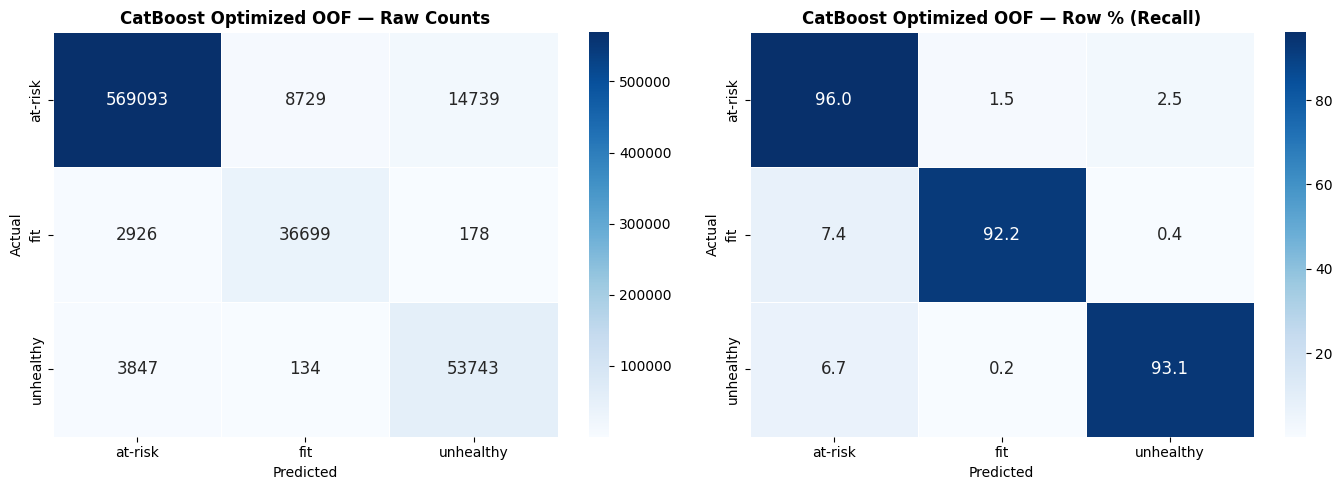

In [23]:
results = evaluate_oof(
    y_true=y,
    probs=oof_probs,
    class_names=le.classes_,
    class_weights=best_weights,
    title="CatBoost Optimized OOF"
)

# Error Analysis

In [24]:
optimized_probs = oof_probs*best_weights
y_pred = optimized_probs.argmax(axis = 1)

error_df, errors = analyze_errors(
    df=train,
    y_true=y,
    y_pred=y_pred,
    label_encoder=le,
    analysis_cols=[
        "stress_level",
        "physical_activity_level",
        "sleep_quality"
    ]
)

Total errors: 30,553 (4.43%)

Errors by TRUE class:
y_true
at-risk      23468
unhealthy     3981
fit           3104

Top confusion pairs (true → predicted):
y_true     y_pred   
at-risk    unhealthy    14739
           fit           8729
unhealthy  at-risk       3847
fit        at-risk       2926
           unhealthy      178
unhealthy  fit            134

Errors by stress_level:
stress_level
missing    15103
high        9590
low         4244
medium      1616

Errors by physical_activity_level:
physical_activity_level
active       14930
moderate      6861
sedentary     6279
missing       2483

Errors by sleep_quality:
sleep_quality
poor       11075
average    10190
good        6597
missing     2691
